# Homework Problem Set 2

**Due Monday of Week 5**

#### &#x2705; Owen Sliger

<!-- info warning success danger -->
<div class="alert alert-block alert-info">
    <b>READ THIS: Instructions for doing this homework</b>
    <br><br>
    You are responsible for tracking how you worked on each problem set, and grading your work accordingly.
    <br><br> 
    To earn full credit on your problem set, follow these instructions:
    <ol>
        <li><b>For each problem</b>, start working on it by yourself. During this time, it's okay to use
these resources:
            <ul>
                <li>Your classwork</li>
                <li>The class wiki</li>
                <li>Some online resources like code documentation, stack overflow, and Python tutorials, but don't use anything AI-generated! (yet)</li>
            </ul>
        </li>
        <li>If you get stuck, give at least 20 minutes of focused effort before consulting other resources.</li>
        <li>After 20 minutes of trying without making progress on your own, you can seek help.
            <ul>
                <li>Use these resources, and still earn full credit:
                    <ul>
                        <li>Use the course help hours.</li>
                        <li>Work together with a peer.</li>
                    </ul>
                </li>
                <li>Use these resources, and earn partial credit:
                    <ul>
                        <li>Review the provided example solution for your problem.</li>
                        <li>Review a peer's completed solution.</li>
                        <li>Use a generative AI resource (any bot that automatically generates code and/or explanations for you).</li>
                    </ul>
                </li>
                <li>Avoid doing this if at all possible:
                    <ul>
                        <li>Copy and use code directly from a resource that you couldn't write yourself (be honest with yourself).</li>
                    </ul>
                </li>
            </ul>
        </li>
        <li>Reset your resources and your 20 minutes <b>for each and every problem</b> in the problem set.</li>
        <li>After you are done, re-read each problem carefully. Double-check, does your work solve the problem that was posed? It's up to you to ensure it does. If you think you have a working solution, but you're not certain, design some tests! If you want to triple-check at this point, you can compare your work with the example solutions without any penalty.</li>
        <li>At the bottom of your problem set, fill out the self-grading rubric. For each problem, indicate:
            <ul>
                <li>Whether you were stuck for 20 minutes of focused effort before seeking help.</li>
                <li>The help resources that you used.</li>
                <li>How you verified that your solution was correct.</li>
            </ul>
        </li>
        <li>From these answers, compute your grade and self-report it at the bottom of your problem set.</li>
    </ol>
</div>

The model you worked on over the first few weeks of class is called the Ising model. To see a fully working interactive animation of the Ising model, check this out: https://mattbierbaum.github.io/ising.js/

In this homework, you will build on the code you and your group wrote during class to solve some additional problems cented on the Ising model.

#### &#x2705; Problem 1

Set **T = 0.5**. Complete a simulation to show long-term behavior of your model (at least 10 times as many steps as the number spins. e.g., for 15x15, run at least 2250 steps). **Create visualization of the final state of the lattice after the simulation.**

I am starting with a randomized lattice that becomes more uniform at T = 0.5


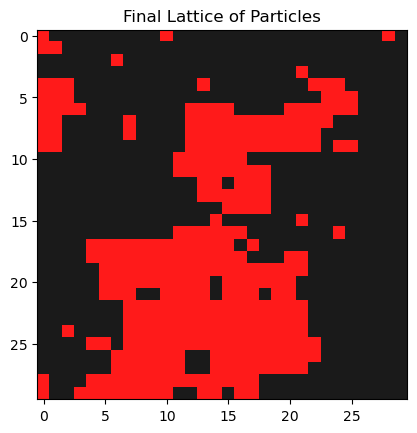

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def rand_lattice(x,y,N,T):
    Paccept = 0
    
#Interating a single possible change
    for i in range(0,N):
        adjacent_sum = 0
        random_x = np.random.randint(0,high=x)
        random_y = np.random.randint(0,high=y)
        random_keepTest = np.random.random()
    
    #Determining the change in energy
        if random_y-1 >= 0:
            adjacent_sum += lattice[random_x,random_y-1]
        if random_x-1 >= 0:
            adjacent_sum += lattice[random_x-1,random_y]
        if random_y+1 < y:
            adjacent_sum += lattice[random_x,random_y+1]
        if random_x+1 < x:
            adjacent_sum += lattice[random_x+1,random_y]

        dE = 2*lattice[random_x,random_y]*adjacent_sum
    
    #Rolling if change is accepted
        if dE <= 0:
            Paccept = 1
        if dE > 0:
            Paccept = np.exp(-dE/T)
        if random_keepTest < Paccept:
            lattice[random_x,random_y] *= (-1)

    return lattice

#Calling function
x=30
y=30
lattice = np.random.randint(2, size=(x,y))-0.5
img = rand_lattice(30,30,18000,0.5);

plt.imshow(img,cmap='flag_r',alpha=0.90)
plt.title('Final Lattice of Particles');

print(f'I am starting with a randomized lattice that becomes more uniform at T = 0.5')

#### &#x2705; Problem 2

Run your simulation from Problem 1 again, and track the total energy and total magnetization of your lattice at every step. **Create two plots:** energy over time and magnetization over time. *Hint: time is measured by steps*

I am starting with a randomized lattice that becomes more uniform at T = 0.5


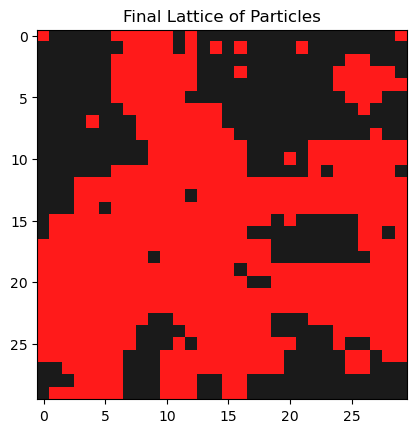

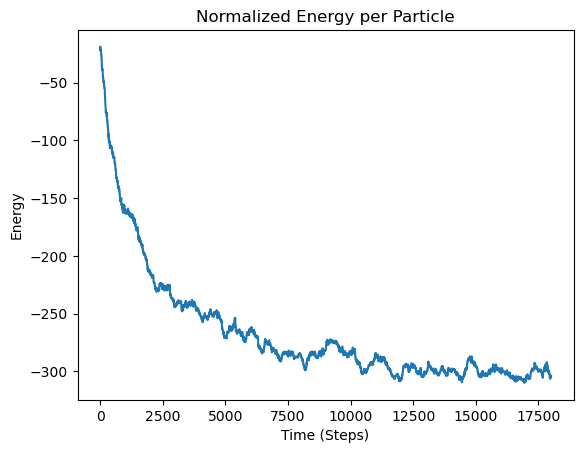

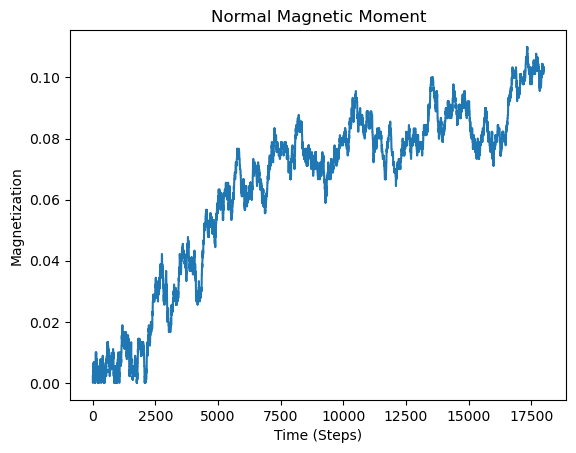

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.close()

def func_lattice(x,y,N,T):
#Initializing function variables and arrays
    Paccept = 0
    spin_total = 0
    energyi = 0
    energy = np.zeros(N+1)
    magnetization_arr = np.arange(0,N)
    
#Calculating intital energy
    for ix in range(0,x):
        for jy in range(0,y):
            adjacent_sum_e = 0
            if jy+1 < y:
                adjacent_sum_e += lattice[ix,jy+1]
            if ix+1 < x:
                adjacent_sum_e += lattice[ix+1,jy]
                
            energyi += (lattice[ix,jy]*adjacent_sum_e)*-1

    energy[0] = energyi

#Iterating a single possible change
    for i in range(0,N):
        adjacent_sum = 0
        random_x = np.random.randint(0,high=x)
        random_y = np.random.randint(0,high=y)
        random_keepTest = np.random.random()
        
        magnetization_arr[i] = np.sum(lattice)
    
    #Determining the change in energy
        if random_y-1 >= 0:
            adjacent_sum += lattice[random_x,random_y-1]
        if random_x-1 >= 0:
            adjacent_sum += lattice[random_x-1,random_y]
        if random_y+1 < y:
            adjacent_sum += lattice[random_x,random_y+1]
        if random_x+1 < x:
            adjacent_sum += lattice[random_x+1,random_y]

        dE = 2*lattice[random_x,random_y]*adjacent_sum
        
    #Rolling if change is accepted
        if dE <= 0:
            Paccept = 1
            
        if dE > 0:
            Paccept = np.exp(-dE/T)
            
        if random_keepTest < Paccept:
            lattice[random_x,random_y] *= (-1)
            energy[i+1] = energy[i] + dE
        else:
            energy[i+1] = energy[i]

    return lattice,x,y,N,energy,magnetization_arr

#Calling function

x = 30
y = 30
lattice = np.random.randint(2, size=(x,y))-0.5
img, x, y, N, energy, magnetization_arr = func_lattice(30,30,18000,0.5);

#Plotting Results
N1 = np.arange(0,N+1)
N2 = np.arange(0,N)

fig_im, ax_im = plt.subplots()
ax_im.imshow(img,cmap='flag_r',alpha=0.90)
ax_im.set( 
    title='Final Lattice of Particles'
)

fig_E, ax_E = plt.subplots()
ax_E.plot(N1,energy)
ax_E.set( 
    xlabel='Time (Steps)',
    ylabel='Energy',
    title='Normalized Energy per Particle'
)

fig_M, ax_M = plt.subplots()
ax_M.plot(N2,abs(magnetization_arr)/(x*y))
ax_M.set( 
    xlabel='Time (Steps)',
    ylabel='Magnetization',
    title='Normal Magnetic Moment'
)

print(f'I am starting with a randomized lattice that becomes more uniform at T = 0.5')

plt.show();

#### &#x2705; Problem 3

Keep T = 0.5. Next, **create two simulations:** one with a random initial lattice, and one with a fully aligned (all up or all down) initial lattice. Run the simulations to show long-term behavior (at least 10 times as many steps as the number spins. e.g., for 15x15, run at least 2250 steps). **Visualize the simulations as animations.**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

x = 30
y = 30
lattice = np.random.randint(2, size=(x,y))-0.5

def lattice_step(x,y,N,T):
    Paccept = 0
    
#Interating a single possible change
    for i in range(0,N):
        adjacent_sum = 0
        random_x = np.random.randint(0,high=x)
        random_y = np.random.randint(0,high=y)
        random_keepTest = np.random.random()

    #Determining the change in energy
        if random_y-1 >= 0:
            adjacent_sum += lattice[random_x,random_y-1]
        if random_x-1 >= 0:
            adjacent_sum += lattice[random_x-1,random_y]
        if random_y+1 < y:
            adjacent_sum += lattice[random_x,random_y+1]
        if random_x+1 < x:
            adjacent_sum += lattice[random_x+1,random_y]

        dE = 2*lattice[random_x,random_y]*adjacent_sum

    #Rolling if change is accepted
        if dE <= 0:
            Paccept = 1
        if dE > 0:
            Paccept = np.exp(-dE/T)
        if random_keepTest < Paccept:
            lattice[random_x,random_y] *= (-1)

#Calling function
plt.rcParams["animation.html"] = "jshtml" 
plt.rcParams['figure.dpi'] = 100
plt.ioff()
fig_anim, ax_anim = plt.subplots()

def animate(frame):
    plt.cla()
    lattice_step(30,30,180,0.5)
    ax_anim.imshow(lattice,cmap='flag_r',alpha=0.90)
    ax_anim.set(title='Lattice of Particles from Random Intitial State')
    
FuncAnimation(fig_anim, animate, frames=100)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

x = 30
y = 30
lattice = (np.zeros((x,y))+0.5)

def lattice_step(x,y,N,T):
    Paccept = 0
    
#Interating a single possible change
    for i in range(0,N):
        adjacent_sum = 0
        random_x = np.random.randint(0,high=x)
        random_y = np.random.randint(0,high=y)
        random_keepTest = np.random.random()

    #Determining the change in energy
        if random_y-1 >= 0:
            adjacent_sum += lattice[random_x,random_y-1]
        if random_x-1 >= 0:
            adjacent_sum += lattice[random_x-1,random_y]
        if random_y+1 < y:
            adjacent_sum += lattice[random_x,random_y+1]
        if random_x+1 < x:
            adjacent_sum += lattice[random_x+1,random_y]

        dE = 2*lattice[random_x,random_y]*adjacent_sum

    #Rolling if change is accepted
        if dE <= 0:
            Paccept = 1
        if dE > 0:
            Paccept = np.exp(-dE/T)
        if random_keepTest < Paccept:
            lattice[random_x,random_y] *= (-1)

#Calling function
plt.rcParams["animation.html"] = "jshtml" 
plt.rcParams['figure.dpi'] = 100
plt.ioff()
fig_anim, ax_anim = plt.subplots()

def animate(frame):
    plt.cla()
    lattice_step(30,30,180,0.5)
    ax_anim.imshow(lattice,cmap='flag_r',alpha=0.90)
    ax_anim.set(title='Lattice of Particles from Uniform State')
    
FuncAnimation(fig_anim, animate, frames=100)

#### &#x2705; Problem 4

For this problem, start simulations with a random lattices, not aligned. Run your Ising model for at least 50 different temperatures, and at least 500 steps per simulation. Choose a range of temperatures that goes across a region of "very magnetized" to "not very magnetized." **Create two plots.** Plot the final energies of the simulations over temperature, and plot the final magnetizations of the simulations over temperature.

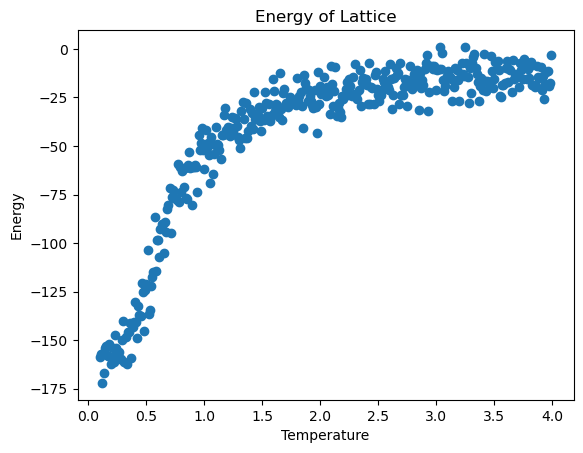

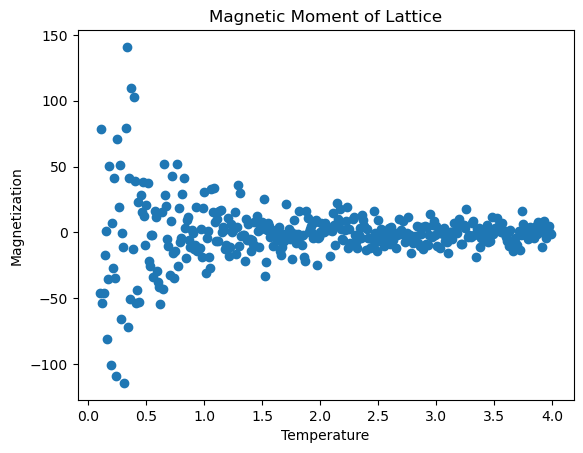

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.close()

def lattice(x,y,N,T):
    
    Paccept = 0
    spin_total = 0
    lattice = np.random.randint(2, size=(x,y))-0.5
    energy = 0
    
    for ix in range(0,x):
            for jy in range(0,y):
                adjacent_sum_e = 0
                if jy+1 < y:
                    adjacent_sum_e += lattice[ix,jy+1]
                if ix+1 < x:
                    adjacent_sum_e += lattice[ix+1,jy]

                energy += (lattice[ix,jy]*adjacent_sum_e)*-1
    
    for i in range(0,N):
        adjacent_sum = 0
        random_x = np.random.randint(0,high=x)
        random_y = np.random.randint(0,high=y)
        random_keepTest = np.random.random()

        if random_y-1 >= 0:
            adjacent_sum += lattice[random_x,random_y-1]
        if random_x-1 >= 0:
            adjacent_sum += lattice[random_x-1,random_y]
        if random_y+1 < y:
            adjacent_sum += lattice[random_x,random_y+1]
        if random_x+1 < x:
            adjacent_sum += lattice[random_x+1,random_y]

        dE = 2*lattice[random_x,random_y]*adjacent_sum

        if dE <= 0:
            Paccept = 1
        if dE > 0:
            Paccept = np.exp(-dE/T)
        if random_keepTest < Paccept:
            lattice[random_x,random_y] *= (-1)
            energy += dE

        if i >= 3*N/4:
            spin_total += np.sum(lattice)

    spin_avg = spin_total/(N/4)
    magnetization = (spin_avg)

    return magnetization,energy

T_arr = np.arange(0.1,4,0.01)
trials = T_arr.size
magnet_arr = np.zeros(trials)
energy_arr = np.zeros(trials)

for i in range(trials):
    magnet_arr[i],energy_arr[i] = lattice(20,20,4000,T_arr[i]);

fig_E1, ax_E1 = plt.subplots()
ax_E1.scatter(T_arr,energy_arr)
ax_E1.set( 
    xlabel='Temperature',
    ylabel='Energy',
    title='Energy of Lattice'
)

fig_M2, ax_M2 = plt.subplots()
ax_M2.scatter(T_arr,(magnet_arr))
ax_M2.set( 
    xlabel='Temperature',
    ylabel='Magnetization',
    title='Magnetic Moment of Lattice'
)

plt.show();

#### &#x2705; Problem 5

Rewrite your energy function to include a magnetic field term, based on this equation:

$$E_B = -\vec{\mu} \cdot \vec{B}$$

where $\vec{\mu}$ is magnetization, and $\vec{B}$ is magnetic field.

In [ ]:
for ix in range(0,x):
            for jy in range(0,y):
                adjacent_sum_e = 0
                if jy+1 < y:
                    adjacent_sum_e += lattice[ix,jy+1]
                if ix+1 < x:
                    adjacent_sum_e += lattice[ix+1,jy]

                energy_sum += (lattice[ix,jy]*adjacent_sum_e)*-1

energy_tot = energy_sum - magnetization * B

#### &#x2705; Problem 6

Set **T = 0.5.** For this problem, start simulations with a random lattices, not aligned. Run your Ising model for the **range of magnetic field values** provided below, with at least 500 steps per simulation. **Create two plots.** Plot the final **energies** of the simulations over temperature, and plot the final **magnetizations** of the simulations over temperature.

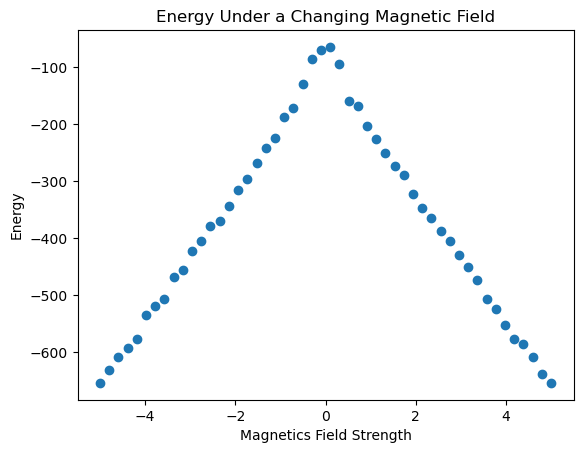

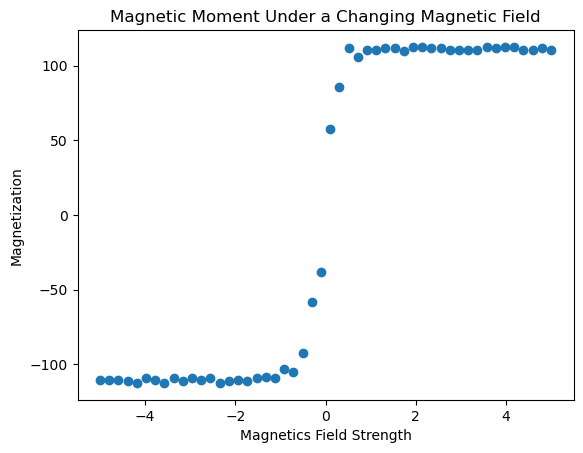

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.close()

B = np.linspace(-5, 5, 50)
trials = B.size
magnet_arr = np.zeros(trials)
energy_arr = np.zeros(trials)

def lattice_magnetized(x,y,N,T,B):
    
    lattice = np.random.randint(2, size=(x,y))-0.5

    for i in range(0,N):
        temp_lattice = lattice.copy()
        energy_sum = 0
        energyf_sum = 0
        new_energy_sum = 0
        Paccept = 0
        spin_total = 0
        energy_tot = 0
        new_energy_tot = 0
        magnetization = 0
        magnetization_final = 0
        energy_final = 0
        
        for ix in range(0,x):
            for jy in range(0,y):
                adjacent_sum_e = 0
                if jy+1 < y:
                    adjacent_sum_e += lattice[ix,jy+1]
                if ix+1 < x:
                    adjacent_sum_e += lattice[ix+1,jy]

                energy_sum += (lattice[ix,jy]*adjacent_sum_e)*-1
                
        magnetization = np.sum(lattice)
        energy_tot = energy_sum - (magnetization * B)
        
        random_x = np.random.randint(0,high=x)
        random_y = np.random.randint(0,high=y)
        random_keepTest = np.random.random()
        temp_lattice[random_x,random_y] *= -1
        
        for ix in range(0,x):
            for jy in range(0,y):
                adjacent_sum = 0
                if jy+1 < y:
                    adjacent_sum += temp_lattice[ix,jy+1]
                if ix+1 < x:
                    adjacent_sum += temp_lattice[ix+1,jy]
                    
                new_energy_sum += (temp_lattice[ix,jy]*adjacent_sum)*-1
                    
        new_magnetization = np.sum(temp_lattice)
        new_energy_tot = new_energy_sum - (new_magnetization * B)
        
        dE = new_energy_tot - energy_tot

        if dE <= 0:
            Paccept = 1
        if dE > 0:
            Paccept = np.exp(-dE/T)
        if random_keepTest < Paccept:
            lattice[random_x,random_y] *= (-1)
    
    magnetization_final = np.sum(lattice)
    
    for ix in range(0,x):
        for jy in range(0,y):
            adjacent_sum_e = 0
            if jy+1 < y:
                adjacent_sum_e += lattice[ix,jy+1]
            if ix+1 < x:
                adjacent_sum_e += lattice[ix+1,jy]

            energyf_sum += (lattice[ix,jy]*adjacent_sum_e)*-1
            
    energy_final = energyf_sum - (magnetization_final * B)

    return magnetization_final,energy_final

for i in range(trials):
    magnet_arr[i],energy_arr[i]= lattice_magnetized(15,15,1000,0.5,B[i]);

fig_E1, ax_E1 = plt.subplots()
ax_E1.scatter(B,energy_arr)
ax_E1.set( 
    xlabel='Magnetics Field Strength',
    ylabel='Energy',
    title='Energy Under a Changing Magnetic Field'
)

fig_M2, ax_M2 = plt.subplots()
ax_M2.scatter(B,(magnet_arr))
ax_M2.set( 
    xlabel='Magnetics Field Strength',
    ylabel='Magnetization',
    title='Magnetic Moment Under a Changing Magnetic Field'
)

plt.show();

## &#x2705; Self-grading

#### &#x2705; Self-grading Problem 1

For **Problem 1**, fill out your answers to these questions:

*Did you seek help from any people/resources? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

No I did not

*Were stuck for 20 minutes of focused effort before seeking help? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

I did not get stuck

*Which help resources did you use? Could be: course help hours, working together with a peer, the example solutions, a peer's completed solution, generative AI chatbot, other.*

I only used previous notebooks I worked on

*Did you verify that your solution was correct? If so how? Could be: Re-reading problem to verify desired outcome, making sense of the physics shown, carrying out tests of your code, consulting example solutions, other.*

I re-read the problem, and compared my results to the example Ising model provided. I feel that my simulation is correct because the end model is clearly not randomized anymore, and had gained some magnetization, which is expected for a lattice of atoms under the influence of a magnetic field at such a low temperature.

#### &#x2705; Self-grading Problem 2

For **Problem 2**, fill out your answers to these questions:

*Did you seek help from any people/resources? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

Yes, after initaially coding my energy as a function of time, the graph looked very strange, so I looked through online forums and websites for what a graph like this should describe. I found that I was not keeping the previous value of energy when the change did not pass, so my energy was always tending towards 0.

*Were stuck for 20 minutes of focused effort before seeking help? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

Yes, I had been tweaking the code for about an hour trying to figuring it out.

*Which help resources did you use? Could be: course help hours, working together with a peer, the example solutions, a peer's completed solution, generative AI chatbot, other.*

Wiki on Ising models, online forums of others asking similar questions.

*Did you verify that your solution was correct? If so how? Could be: Re-reading problem to verify desired outcome, making sense of the physics shown, carrying out tests of your code, consulting example solutions, other.*

Yes, I figure that at a low temperature like T = 0.5, a random lattice will tend towards magnetized as a magentic fields is passed through it. So, the energy will decrease towards -2 (since Im using 1 and -1 as the spin representations) and the magnetization will approach 1. However, they wont reach the values as the lattice will most likely not reach a fully organized lattice of a signle spin. This is exactly what the graphs describe.

#### &#x2705; Self-grading Problem 3

For **Problem 3**, fill out your answers to these questions:

*Did you seek help from any people/resources? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

No I did not

*Were stuck for 20 minutes of focused effort before seeking help? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

Yes, it took about 45 minutes

*Which help resources did you use? Could be: course help hours, working together with a peer, the example solutions, a peer's completed solution, generative AI chatbot, other.*

I only used my information from my previous notebooks

*Did you verify that your solution was correct? If so how? Could be: Re-reading problem to verify desired outcome, making sense of the physics shown, carrying out tests of your code, consulting example solutions, other.*

Yes, i verified my animation with the example model and example solution animations. I am confident in my answer, however I am a little confused as to why there are particles flipping in the example version, but with my model, at T = 0.5, no changes are prefered when the lattice is all spin +1/2 or -1/2. 

#### &#x2705; Self-grading Problem 4

For **Problem 4**, fill out your answers to these questions:

*Did you seek help from any people/resources? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

No I did not.

*Were stuck for 20 minutes of focused effort before seeking help? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

Yes, it took me a while to figure out how to track the energy.

*Which help resources did you use? Could be: course help hours, working together with a peer, the example solutions, a peer's completed solution, generative AI chatbot, other.*

Just my notebooks

*Did you verify that your solution was correct? If so how? Could be: Re-reading problem to verify desired outcome, making sense of the physics shown, carrying out tests of your code, consulting example solutions, other.*

I verified by a logic check. Since I am starting out with a uniform lattice, as time goes by, the magnetization will increase, and the energy will reach a lower state as seen in the graphs.

#### &#x2705; Self-grading Problem 5

For **Problem 5**, fill out your answers to these questions:

*Did you seek help from any people/resources? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

No

*Were stuck for 20 minutes of focused effort before seeking help? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

I was not stuck

*Which help resources did you use? Could be: course help hours, working together with a peer, the example solutions, a peer's completed solution, generative AI chatbot, other.*

Didnt use any resources

*Did you verify that your solution was correct? If so how? Could be: Re-reading problem to verify desired outcome, making sense of the physics shown, carrying out tests of your code, consulting example solutions, other.*

I am only adding the magnetic energy to my original energy equation to find the total energy

#### &#x2705; Self-grading Problem 6

For **Problem 6**, fill out your answers to these questions:

*Did you seek help from any people/resources? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

Yes, I was stuck on this code for a long time and was helped by Alex Montz.

*Were stuck for 20 minutes of focused effort before seeking help? (Besides your class notes, the class wiki, and non-GenAI online resources.)*

Yes, I worked on this for about two hours, getting practically random graphs every time.

*Which help resources did you use? Could be: course help hours, working together with a peer, the example solutions, a peer's completed solution, generative AI chatbot, other.*

Working with a peer

*Did you verify that your solution was correct? If so how? Could be: Re-reading problem to verify desired outcome, making sense of the physics shown, carrying out tests of your code, consulting example solutions, other.*

Yes, I verified with what my peer got and the solution to the homework.

#### That's all! You've reached the end of the homework.

Scroll through to make sure you didn't miss any tasks (marked with &#x2705;). Download your work as an HTML file, by selecting: `File` --> `Save and Export Notebook As...` --> `HTML` inside the JupyterHub interface (don't select your browser's File menu). 

Open your downloaded file to ensure the contents look okay, then submit it on Canvas.